In [2]:
triangles = {
    100: [
        [11],
        [41, 39, 9],
        [14, 8, 37, 29, 25],
        [15, 35, 36, 26, 1, 27, 47],
        [33, 40, 12, 3, 49, 46, 4, 19, 30],
        [22, 7, 38, 45, 5, 2, 44, 31, 21, 6, 43],
        [32, 28, 18, 10, 34, 48, 13, 23, 20, 42, 17, 16, 24],
    ],

    101: [
        [1],
        [15, 47, 38],
        [18, 37, 31, 7, 25],
        [12, 29, 42, 26, 2, 28, 46],
        [40, 43, 6, 4, 49, 45, 5, 16, 34],
        [32, 9, 20, 48, 27, 3, 22, 35, 39, 17, 11],
        [14, 19, 36, 24, 21, 23, 30, 41, 8, 10, 44, 13, 33],
    ],

    102: [
        [15],
        [25, 34, 28],
        [3, 32, 42, 6, 26],
        [24, 39, 36, 22, 2, 30, 44],
        [19, 43, 16, 5, 45, 48, 7, 10, 41],
        [31, 17, 35, 38, 13, 4, 40, 37, 18, 20, 23],
        [11, 14, 46, 12, 9, 47, 33, 21, 8, 27, 49, 1, 29],
    ],

    103: [
        [5],
        [41, 31, 26],
        [32, 2, 28, 40, 9],
        [21, 27, 23, 33, 19, 29, 46],
        [34, 36, 12, 20, 48, 22, 14, 18, 25],
        [44, 8, 17, 35, 39, 13, 3, 49, 37, 11, 30],
        [10, 7, 42, 43, 1, 16, 47, 38, 15, 6, 45, 4, 24],
    ],

    104: [
        [10],
        [34, 21, 39],
        [7, 23, 40, 16, 9],
        [38, 24, 35, 25, 4, 45, 46],
        [14, 44, 8, 20, 41, 30, 29, 3, 26],
        [37, 17, 36, 32, 28, 13, 22, 42, 11, 18, 49],
        [5, 15, 47, 19, 2, 31, 43, 27, 12, 48, 33, 1, 6],
    ],
}

In [3]:
# Explicit order-7 solutions for one of the magic-triangle forms
# I introduced: the 2x2-subtriangle magic triangle (OEIS A375416).
#
# Donghwi Park, Ph.D.

# The entries 1,...,49 are arranged so that every 2x2 subtriangle
# has the same sum. I provide below one explicit solution for each
# magic sum S = 100, 101, 102, 103, 104.
#
# Solutions for S = 99, 98, 97, 96 can be obtained, respectively,
# by replacing every entry x with 50-x in the solutions for
# S = 101, 102, 103, 104.
#
# Thus these constructions provide explicit order-7 solutions for
# every magic sum from 96 through 104.
#
# Rows are listed from top to bottom and left to right, with lengths
# 1, 3, 5, 7, 9, 11, 13.

In [4]:
def print_triangle(triangle):
    max_width = len(triangle[-1]) * 4

    for row in triangle:
        text = " ".join(f"{x:2d}" for x in row)
        print(text.center(max_width))


for number, triangle in triangles.items():
    print(f"\nTriangle {number}")
    print_triangle(triangle)


Triangle 100
                         11                         
                      41 39  9                      
                   14  8 37 29 25                   
                15 35 36 26  1 27 47                
             33 40 12  3 49 46  4 19 30             
          22  7 38 45  5  2 44 31 21  6 43          
       32 28 18 10 34 48 13 23 20 42 17 16 24       

Triangle 101
                          1                         
                      15 47 38                      
                   18 37 31  7 25                   
                12 29 42 26  2 28 46                
             40 43  6  4 49 45  5 16 34             
          32  9 20 48 27  3 22 35 39 17 11          
       14 19 36 24 21 23 30 41  8 10 44 13 33       

Triangle 102
                         15                         
                      25 34 28                      
                    3 32 42  6 26                   
                24 39 36 22  2 30 44                
    

In [5]:
import numpy as np
import matplotlib.pyplot as plt


def plot_triangle(data, title=None, fontsize=13, figsize=(9, 9)):
    """
    Plot a triangular array.

    - All grid lines and numbers are pure black.
    - figsize controls the physical size of the output figure.
    """

    n = len(data)
    h = np.sqrt(3) / 2

    fig, ax = plt.subplots(figsize=figsize)

    # ----------------------------
    # 1. Draw triangular grid
    # ----------------------------

    # Horizontal lines
    for r in range(n + 1):
        y = r * h
        x_left = r / 2
        x_right = n - r / 2

        ax.plot(
            [x_left, x_right],
            [y, y],
            color="black",
            linewidth=1
        )

    # / direction
    for k in range(n + 1):
        x0 = k
        length = n - k

        ax.plot(
            [x0, x0 + length / 2],
            [0, length * h],
            color="black",
            linewidth=1
        )

    # \ direction
    for k in range(n + 1):
        x0 = k
        length = k

        ax.plot(
            [x0, x0 - length / 2],
            [0, length * h],
            color="black",
            linewidth=1
        )

    # ----------------------------
    # 2. Place numbers
    # ----------------------------

    for row_from_top, row in enumerate(data):

        level = n - 1 - row_from_top
        y_base = level * h

        expected = 2 * row_from_top + 1

        if len(row) != expected:
            raise ValueError(
                f"Row {row_from_top + 1} must contain "
                f"{expected} entries, but contains {len(row)}."
            )

        x_start = level / 2

        for j, value in enumerate(row):

            if j % 2 == 0:
                # upward triangle
                x = x_start + j / 2 + 0.5
                y = y_base + h / 3

            else:
                # downward triangle
                x = x_start + (j + 1) / 2
                y = y_base + 2 * h / 3

            ax.text(
                x,
                y,
                str(value),
                ha="center",
                va="center",
                fontsize=fontsize,
                color="black"
            )

    # ----------------------------
    # 3. Figure settings
    # ----------------------------

    ax.set_aspect("equal")
    ax.axis("off")

    ax.set_xlim(-0.1, n + 0.1)
    ax.set_ylim(-0.1, n * h + 0.2)

    if title is not None:
        ax.set_title(
            str(title),
            fontsize=fontsize + 2,
            color="black",
            pad=8
        )

    plt.tight_layout(pad=0.2)
    plt.show()


Magic sum 100


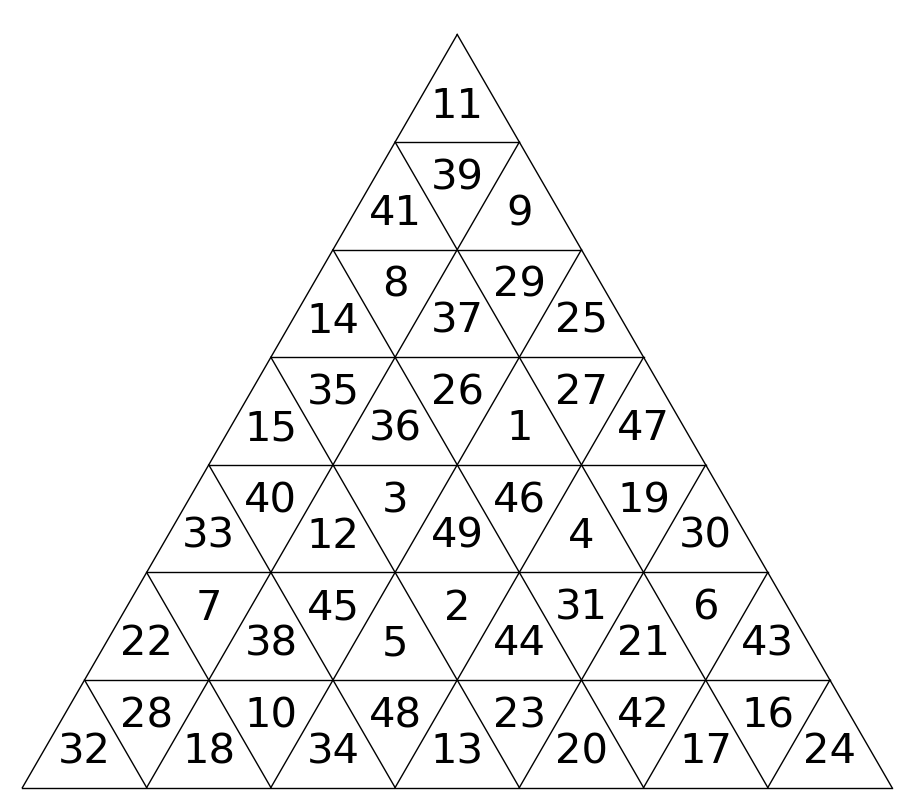


Magic sum 101


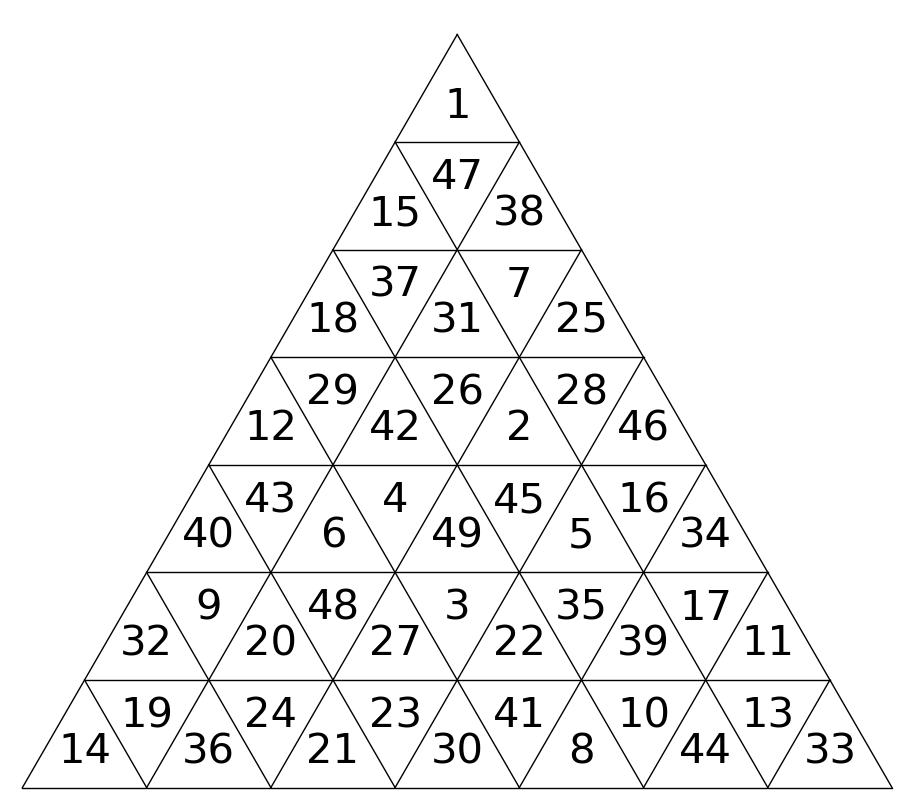


Magic sum 102


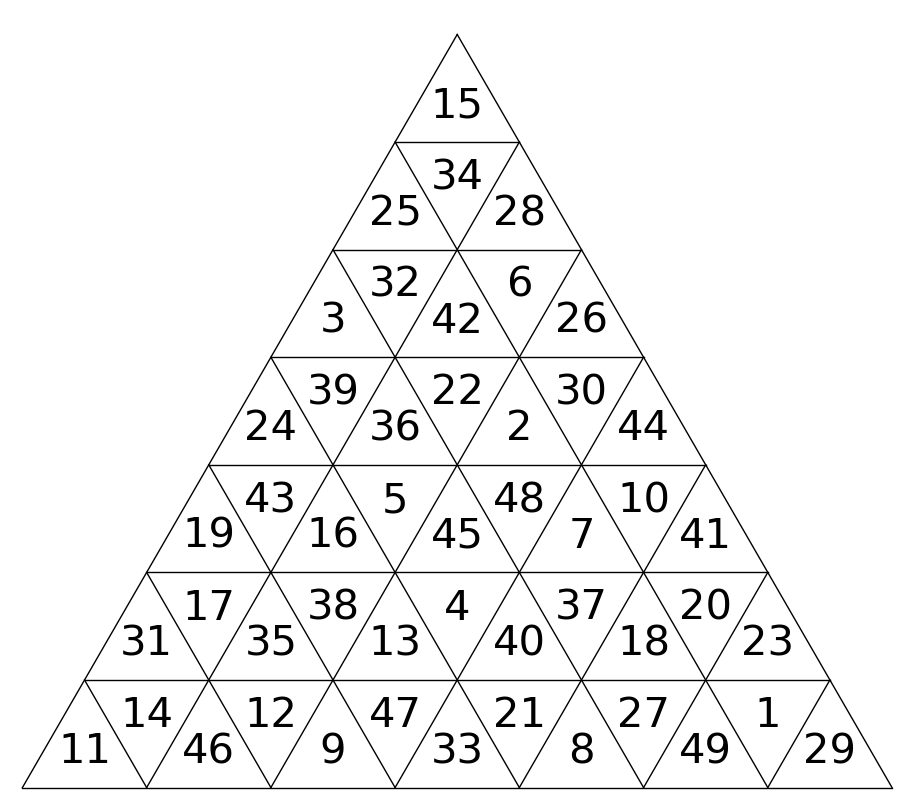


Magic sum 103


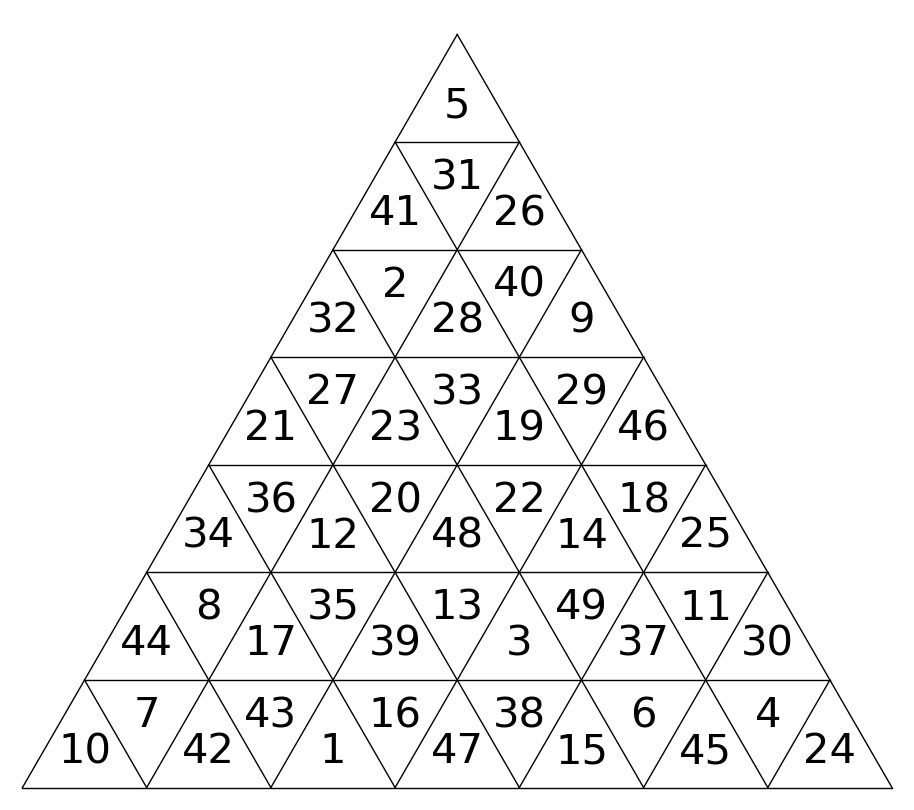


Magic sum 104


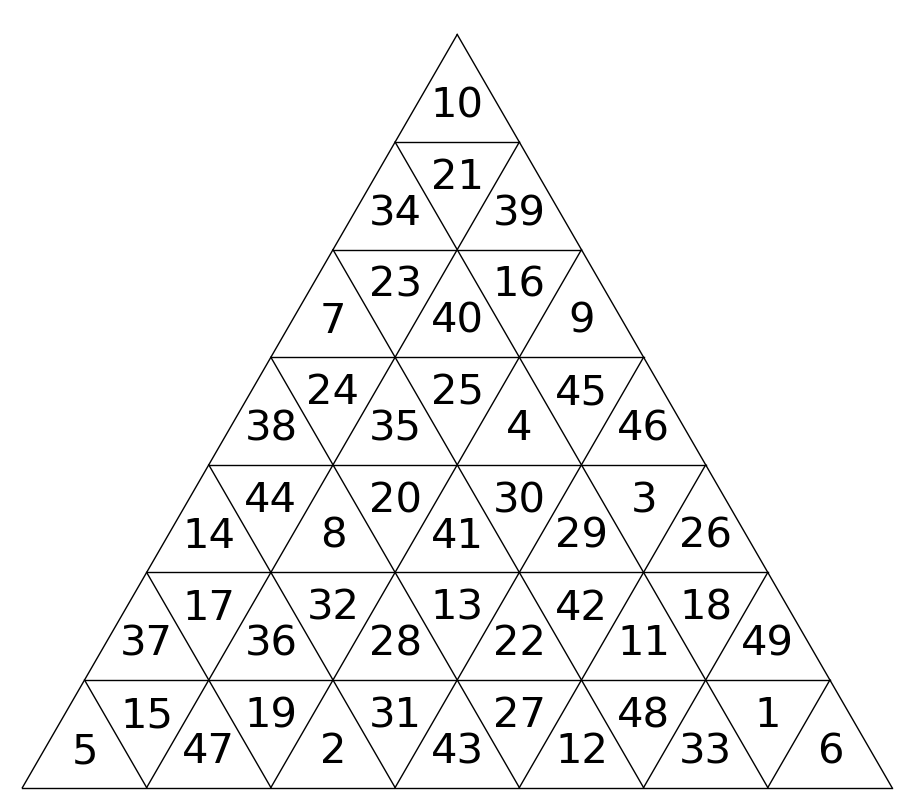

In [6]:
for number, triangle in triangles.items():
    print(f"\nMagic sum {number}")
    plot_triangle(triangle, fontsize=30)

In [7]:
# Representative order-5 solution (magic sum 56).
# All order-5 solutions have already been enumerated.

triangles_n5 = {
    56: [
        [6],
        [23, 5, 22],
        [8, 12, 13, 20, 1],
        [21, 10, 17, 11, 15, 16, 24],
        [7, 9, 19, 18, 2, 14, 25, 3, 4],
    ],
}
# Representative order-6 solution (magic sum 74).
triangles_n6 = {
    74: [
        [33],
        [2, 10, 29],
        [17, 34, 21, 18, 6],
        [4, 28, 25, 1, 27, 11, 30],
        [31, 13, 26, 20, 3, 35, 9, 23, 12],
        [5, 24, 14, 15, 19, 16, 36, 7, 22, 8, 32],
    ],
}

# Representative order-4 solution (magic sum 34).

triangles_n4 = {
    34: [
        [12],
        [10, 9, 3],
        [7, 1, 16, 13, 2],
        [14, 5, 8, 4, 6, 11, 15],
    ],
}

order 5

Magic sum 56


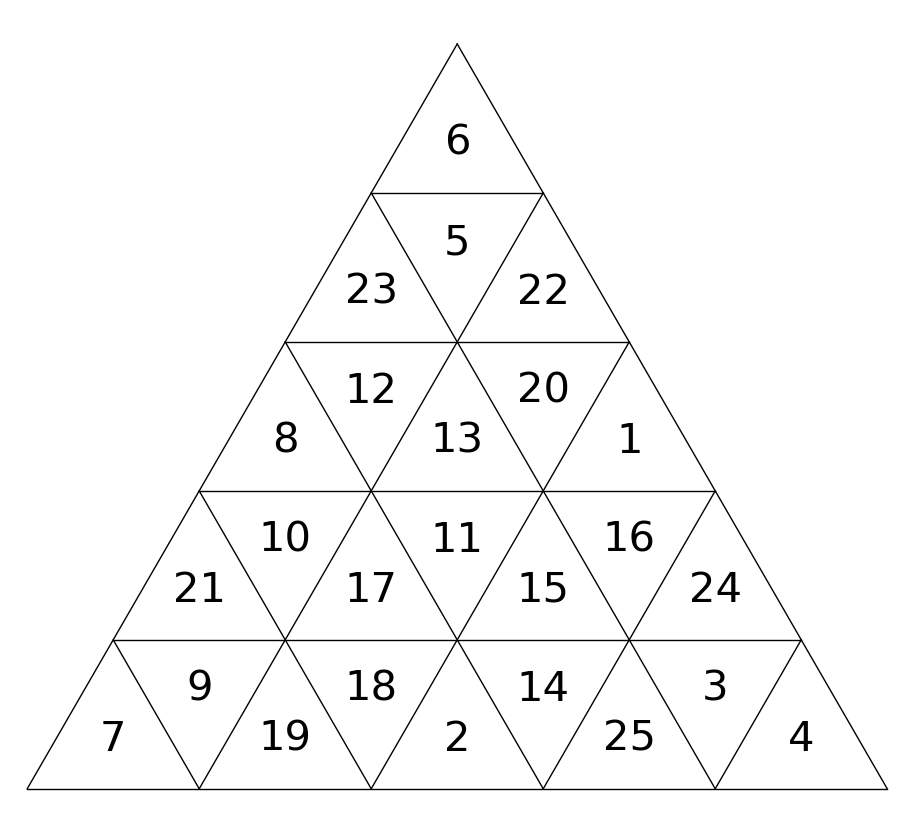

For order 5, every magic sum from 48 through 56 is possible.
Additional example solutions are omitted here.


In [8]:
print("order 5")
for number, triangle in triangles_n5.items():
    print(f"\nMagic sum {number}")
    plot_triangle(triangle, fontsize=30)
print(
    "For order 5, every magic sum from 48 through 56 is possible.\n"
    "Additional example solutions are omitted here."
)

order 6

Magic sum 74


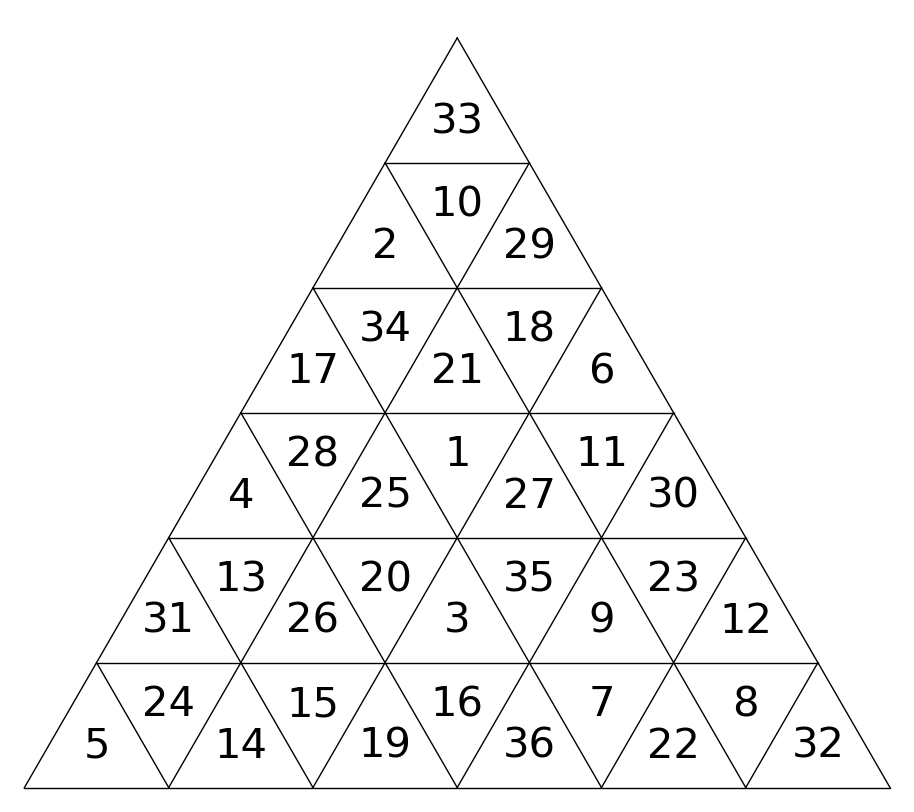

In [9]:
print("order 6")
for number, triangle in triangles_n6.items():
    print(f"\nMagic sum {number}")
    plot_triangle(triangle, fontsize=30)

order 4

Magic sum 34


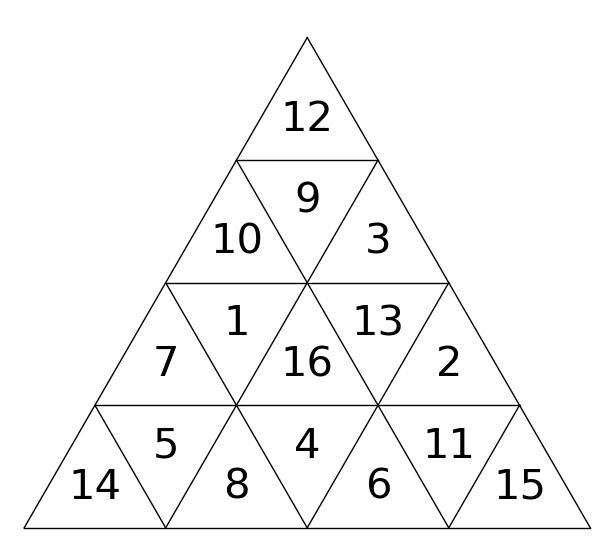

In [10]:
print("order 4")
for number, triangle in triangles_n4.items():
    print(f"\nMagic sum {number}")
    plot_triangle(triangle, fontsize=30,
    figsize=(6, 6))

In [11]:
print(
    "Orders 1 and 2 are omitted because they are trivial.\n"
    "Order 3 is also omitted because it can be easily related to\n"
    "Trotter's perimeter-magic triangle of order 4.\n"
    "Exceptionally, for order 3 the possible magic sums are not consecutive:\n"
    "M = 17, 19, 20, 21, and 23."
)

Orders 1 and 2 are omitted because they are trivial.
Order 3 is also omitted because it can be easily related to
Trotter's perimeter-magic triangle of order 4.
Exceptionally, for order 3 the possible magic sums are not consecutive:
M = 17, 19, 20, 21, and 23.


Proof that magic sums 105 and 95 are impossible 
 for an order-7 (7x7) magic triangle.
Number of times each unit triangle is counted when 
every 2x2 subtriangle is taken exactly once.
A total of 31 subtriangles are taken.


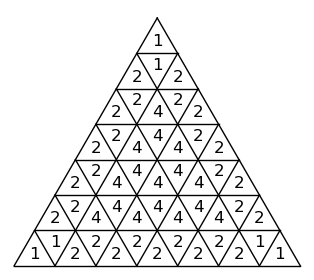

In [12]:
print("Proof that magic sums 105 and 95 are impossible \n for an order-7 (7x7) magic triangle.")

triangle_a = [
    [1],
    [2, 1, 2],
    [2, 2, 4, 2, 2],
    [2, 2, 4, 4, 4, 2, 2],
    [2, 2, 4, 4, 4, 4, 4, 2, 2],
    [2, 2, 4, 4, 4, 4, 4, 4, 4, 2, 2],
    [1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1],
]
print("Number of times each unit triangle is counted when \n"
      "every 2x2 subtriangle is taken exactly once.\n"
      "A total of 31 subtriangles are taken.")

plot_triangle(
    triangle_a,
    fontsize=12,
    figsize=(3, 3)
)

After subtracting twice the contribution of the central 4x4 subtriangle,
the resulting linear combination is equivalent to taking a net total
of 23 2x2 subtriangles.


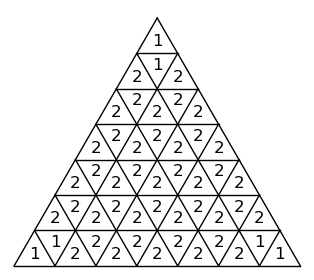

In [13]:
triangle_b = [
    [1],
    [2, 1, 2],
    [2, 2, 2, 2, 2],
    [2, 2, 2, 2, 2, 2, 2],
    [2, 2, 2, 2, 2, 2, 2, 2, 2],
    [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
    [1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1],
]

print(
    "After subtracting twice the contribution of the central 4x4 subtriangle,\n"
    "the resulting linear combination is equivalent to taking a net total\n"
    "of 23 2x2 subtriangles."
)

plot_triangle(
    triangle_b,
    fontsize=12,
    figsize=(3, 3)
)

Then, take each of the three corner subtriangles once more.
The resulting linear combination is equivalent to taking a net total
of 26 2x2 subtriangles.


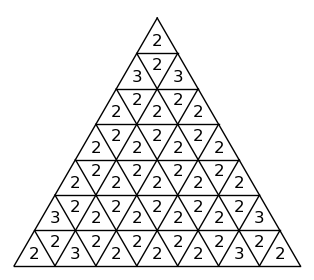

Let M denote the magic sum. Then
26M = 49*50 + (sum of the six indicated entries).
If M = 105, the sum of the six indicated entries must be 280.


In [14]:
triangle_c = [
    [2],
    [3, 2, 3],
    [2, 2, 2, 2, 2],
    [2, 2, 2, 2, 2, 2, 2],
    [2, 2, 2, 2, 2, 2, 2, 2, 2],
    [3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3],
    [2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2],
]

print(
    "Then, take each of the three corner subtriangles once more.\n"
    "The resulting linear combination is equivalent to taking a net total\n"
    "of 26 2x2 subtriangles."
)

plot_triangle(
    triangle_c,
    fontsize=12,
    figsize=(3, 3)
)

print(
    "Let M denote the magic sum. Then\n"
    "26M = 49*50 + (sum of the six indicated entries).\n"
    "If M = 105, the sum of the six indicated entries must be 280."
)

Now consider a different combination of 13 subtriangles:
take the three 4x4 subtriangles containing the three vertices,
together with the central inverted 2x2 subtriangle.
In this combination, only the three unit triangles at the midpoints
of the three sides are counted twice; every other unit triangle is counted once.


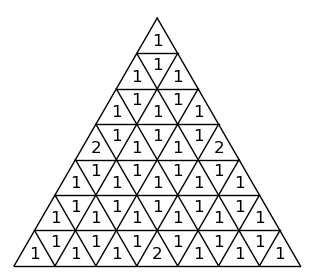

Let M denote the magic sum. Then
13M = 49*50/2 + (sum of the three indicated entries).
If M = 105, the sum of the three indicated entries must be 140.


In [15]:
print(
    "Now consider a different combination of 13 subtriangles:\n"
    "take the three 4x4 subtriangles containing the three vertices,\n"
    "together with the central inverted 2x2 subtriangle.\n"
    "In this combination, only the three unit triangles at the midpoints\n"
    "of the three sides are counted twice; every other unit triangle is counted once."
)

triangle_1a = [
    [1],
    [1, 1, 1],
    [1, 1, 1, 1, 1],
    [2, 1, 1, 1, 1, 1, 2],
    [1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1],
]
plot_triangle(
    triangle_1a,
    fontsize=12,
    figsize=(3, 3)
)


print(
    "Let M denote the magic sum. Then\n"
    "13M = 49*50/2 + (sum of the three indicated entries).\n"
    "If M = 105, the sum of the three indicated entries must be 140."
)

The combined construction has a net total of 39 subtriangles.
Every unit triangle is counted three times, except for the nine indicated
unit triangles, each of which is counted once more.
Therefore, the sum of the entries in these nine unit triangles is
39M - 3*(49*50/2).
If M = 105, this sum must be
39*105 - 3*(49*50/2) = 420.
However, the maximum possible sum of any nine distinct entries from 1,...,49 is
41 + 42 + ... + 49 = 405.
Since 420 > 405, this is a contradiction. Therefore, M = 105 is impossible.


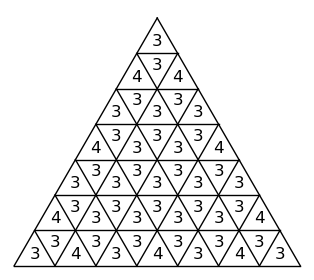

By complement symmetry (x -> 50-x), the impossibility of M = 105
also implies the impossibility of M = 95.
Since explicit solutions for M = 96, 97, ..., 104 were given above,
the possible magic sums for order 7 are exactly 96 through 104.


In [16]:
triangle_final = [
    [3],
    [4, 3, 4],
    [3, 3, 3, 3, 3],
    [4, 3, 3, 3, 3, 3, 4],
    [3, 3, 3, 3, 3, 3, 3, 3, 3],
    [4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4],
    [3, 3, 4, 3, 3, 3, 4, 3, 3, 3, 4, 3, 3],
]

print(
    "The combined construction has a net total of 39 subtriangles.\n"
    "Every unit triangle is counted three times, except for the nine indicated\n"
    "unit triangles, each of which is counted once more.\n"
    "Therefore, the sum of the entries in these nine unit triangles is\n"
    "39M - 3*(49*50/2)."
)

print(
    "If M = 105, this sum must be\n"
    "39*105 - 3*(49*50/2) = 420.\n"
    "However, the maximum possible sum of any nine distinct entries from 1,...,49 is\n"
    "41 + 42 + ... + 49 = 405.\n"
    "Since 420 > 405, this is a contradiction. Therefore, M = 105 is impossible."
)
plot_triangle(
    triangle_final,
    fontsize=12,
    figsize=(3, 3)
)
print(
    "By complement symmetry (x -> 50-x), the impossibility of M = 105\n"
    "also implies the impossibility of M = 95.\n"
    "Since explicit solutions for M = 96, 97, ..., 104 were given above,\n"
    "the possible magic sums for order 7 are exactly 96 through 104."
)